Install all the necessary packages

In [2]:
pip install torch torchvision matplotlib numpy

Import all the packages

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

Creation of synthetic data


In [4]:
IMAGE_SIZE = 50
NUM_SAMPLES = 5000
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [5]:
class HotPixelDataset(Dataset):
  def __init__(self, size=1000, img_dim=50):
        self.size = size
        self.img_dim = img_dim

  def __len__(self):
    return self.size

  def __getitem__(self, idx):
        # Create a black image (1 channel, height, width)
        image = torch.zeros((1, self.img_dim, self.img_dim), dtype=torch.float32)

        # Randomly select coordinates
        x = np.random.randint(0, self.img_dim)
        y = np.random.randint(0, self.img_dim)

        # Set pixel to 1.0 (representing 255 normalized)
        image[0, y, x] = 1.0

        # Normalize targets for better regression performance
        # We predict (x, y) as values between 0 and 1
        target = torch.tensor([x / self.img_dim, y / self.img_dim], dtype=torch.float32)

        return image, target

Data Splitting and DataLoder Configuration

Two seperate datasets are created: one for thr training and the other for validation.
The training dataset consists of NUM_SAMPLES (5,000) synthetic images, each of size 50x50 pixels. Every image contains exactly one active (white) pixel with a value of 255 (normalized to 1.0), placed at a random location. The corresponding label stores the normalized (x, y) coordinates of this active pixel.

The validation dataset contains 1,000 independently generated samples following the same data distribution. This separation ensures that the model is evaluated on unseen data, allowing us to assess its generalization capability rather than memorization.

In [6]:
train_dataset = HotPixelDataset(size=NUM_SAMPLES, img_dim=IMAGE_SIZE)
val_dataset = HotPixelDataset(size=1000, img_dim=IMAGE_SIZE)

# DataLoader is used to efficiently load the data in mini-batches during training and validation

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

The model is trained using Mean Squared Error (MSE) loss, which measures how far the predicted coordinates are from the true pixel coordinates. The Adam optimizer is used to update the model weights efficiently.

During each epoch, the model learns from the training data and the average training loss is recorded. After training, the model is evaluated on validation data without updating weights, and the validation loss is also recorded. These losses help track how well the model is learning.



A lightweight Convolutional Neural Network (CNN) is used to extract spatial features from the input image and regress the corresponding (x, y) coordinates of the active pixel.


In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []

print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)


    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

Starting Training...
Epoch [1/10], Train Loss: 0.022382, Val Loss: 0.001125
Epoch [2/10], Train Loss: 0.000705, Val Loss: 0.000357
Epoch [3/10], Train Loss: 0.000353, Val Loss: 0.000235
Epoch [4/10], Train Loss: 0.000195, Val Loss: 0.000178
Epoch [5/10], Train Loss: 0.000156, Val Loss: 0.000132
Epoch [6/10], Train Loss: 0.000124, Val Loss: 0.000185
Epoch [7/10], Train Loss: 0.000116, Val Loss: 0.000101
Epoch [8/10], Train Loss: 0.000078, Val Loss: 0.000073
Epoch [9/10], Train Loss: 0.000083, Val Loss: 0.000056
Epoch [10/10], Train Loss: 0.000056, Val Loss: 0.000082


This function displays sample images and compares the true pixel location (green circle) with the model’s predicted location (red cross). It helps visually verify how accurately the model identifies the active pixel position.

In [ ]:
def visualize_predictions(model, dataset, num_visualizations=5):
    model.eval()
    fig, axes = plt.subplots(1, num_visualizations, figsize=(15, 3))

    indices = np.random.choice(len(dataset), num_visualizations, replace=False)

    for i, idx in enumerate(indices):
        image, target = dataset[idx]
        image_input = image.unsqueeze(0).to(device) # Add batch dim

        with torch.no_grad():
            pred = model(image_input).cpu().squeeze().numpy()

        # Denormalize coordinates for display
        true_x = int(target[0] * IMAGE_SIZE)
        true_y = int(target[1] * IMAGE_SIZE)
        pred_x = int(pred[0] * IMAGE_SIZE)
        pred_y = int(pred[1] * IMAGE_SIZE)

        # Plot
        axes[i].imshow(image.squeeze(), cmap='gray')
        # Plot True (Green Circle)
        axes[i].scatter(true_x, true_y, c='green', s=100, marker='o', label='True', facecolors='none', edgecolors='green')
        # Plot Predicted (Red x)
        axes[i].scatter(pred_x, pred_y, c='red', s=50, marker='x', label='Pred')

        axes[i].set_title(f"True:({true_x},{true_y})\nPred:({pred_x},{pred_y})")
        axes[i].axis('off')

    # Create a single legend for the figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.show()

This plot shows training and validation loss over epochs to track learning progress. After training, sample predictions on the validation set are visualized to compare true and predicted pixel locations.

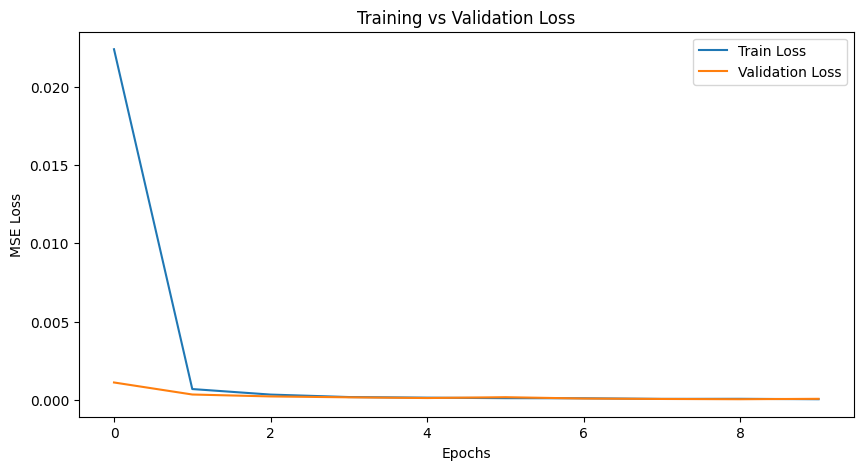


Visualizing predictions on validation set...


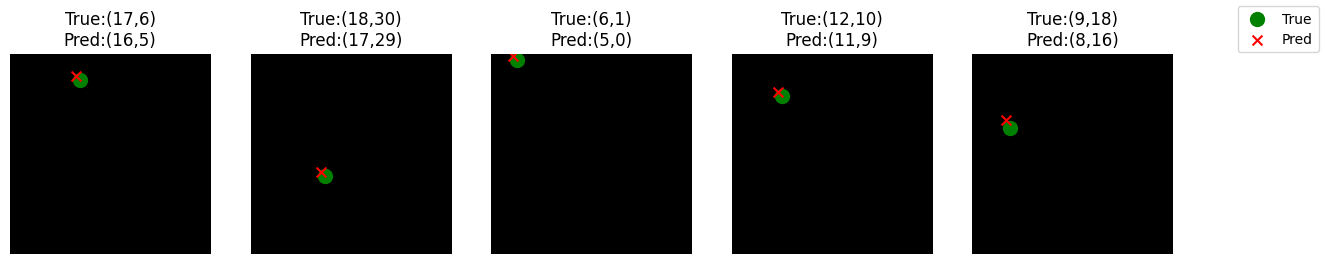

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# Show visual examples
print("\nVisualizing predictions on validation set...")
visualize_predictions(model, val_dataset)